# Second level analysis: ANOVA + KMeans on cue offset


1. calculate one-way anova 
2. look at comparison with the original one-way anova for feedback effects


*Yiyu Wang 2024 September*


In [1]:
import os
import glob
import nibabel as nib
import numpy as np
import pandas as pd

from nilearn.image import new_img_like, concat_imgs, mean_img, math_img
from nilearn import plotting
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from scipy.stats import norm
import scipy.stats as stats
from nilearn.maskers import NiftiLabelsMasker


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import math

import seaborn as sns
import matplotlib.pyplot as plt
from os.path import join


from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform


cluster_colors = ['#FFC800', '#7A3EB1', '#F76800'] 

def lighten_color(color, amount=0.5):
    import colorsys
    import matplotlib
    try:
        c = matplotlib.colors.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*matplotlib.colors.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])




/Users/yiyuwang/anaconda3/envs/neuroimaging_env/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
# local directory set up
gm_mask_img = nib.load('masks/gm_mask_icbm152_brain.nii.gz')

subjects_list = pd.read_csv('Data/included_SocialPred_subjects.csv', header=None)
subjects_list = subjects_list[0].values.tolist()
sample_n = len(subjects_list)
print("subjects in this analysis:")
print(subjects_list)
print(f"**** n = {sample_n} *****" )


TR = .001
N_TR = 675
TR_Length = 0.8
TR_IN_MS = int(TR_Length/TR)

fwhm = 0



subjects in this analysis:
[152, 179, 154, 158, 173, 153, 159, 174, 162, 145, 143, 181, 144, 169, 146, 167, 161, 182, 147, 166, 160, 185, 170, 176, 151, 157, 171, 177, 150, 156]
**** n = 30 *****


In [3]:
# omnibus anova test in design matrix

model = 'model_cue_offset'

beta_dir = f'Results/{model}/1stLvl/'

second_level_res_dir = f'Results/{model}/omnibus_anova_F/'
if not os.path.isdir(second_level_res_dir):
    os.makedirs(second_level_res_dir)


vmax = 5
cluster_thre = 30
p_val = 0.05
p_unc = norm.isf(p_val)

p001 = 0.001
p001_unc = norm.isf(p001)

alpha = 0.05


# Regression model with an omnibus ANOVA design

In [4]:
# design matrix for one sample test

file_list = []

obs_pattern, obs_social, fb_pattern_congruent, fb_social_congruent, fb_pattern_PE, fb_social_PE = [], [], [], [], [], []
for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*obs_Pattern*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(1)
        obs_social.append(0)
        fb_pattern_congruent.append(0)
        fb_social_congruent.append(0)
        fb_pattern_PE.append(0)
        fb_social_PE.append(0)
    else:
        print(f"no obs pattern for subject {s}")
for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*obs_Social*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(0)
        obs_social.append(1)
        fb_pattern_congruent.append(0)
        fb_social_congruent.append(0)
        fb_pattern_PE.append(0)
        fb_social_PE.append(0)
    else:
        print(f"no obs social for subject {s}")

for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*fb_Social_Congruent*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(0)
        obs_social.append(0)
        fb_pattern_congruent.append(0)
        fb_social_congruent.append(1)
        fb_pattern_PE.append(0)
        fb_social_PE.append(0)
    else:
        print(f"no fb social congruent for subject {s}")

for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*fb_Social_PE*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(0)
        obs_social.append(0)
        fb_pattern_congruent.append(0)
        fb_social_congruent.append(0)
        fb_pattern_PE.append(0)
        fb_social_PE.append(1)
    else:
        print(f"no fb social PE for subject {s}")

for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*fb_Pattern_Congruent*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(0)
        obs_social.append(0)
        fb_pattern_congruent.append(1)
        fb_social_congruent.append(0)
        fb_pattern_PE.append(0)
        fb_social_PE.append(0)
    else:
        print(f"no fb pattern congruent for subject {s}")
for s in subjects_list:
    file_name = glob.glob(beta_dir + f'{s}/sub-{s}*z_score*fb_Pattern_PE*.nii.gz')
    if len(file_name) != 0:
        file_list.append(file_name[0])
        obs_pattern.append(0)
        obs_social.append(0)
        fb_pattern_congruent.append(0)
        fb_social_congruent.append(0)
        fb_pattern_PE.append(1)
        fb_social_PE.append(0)
    else:
        print(f"no fb pattern PE for subject {s}")
        
second_level_input = file_list

design_columns = ['obs_Pattern', 'obs_Social', 'fb_Pattern_Congruent', 'fb_Social_Congruent', 'fb_Pattern_PE', 'fb_Social_PE']

X = pd.concat([pd.Series(obs_pattern), 
               pd.Series(obs_social),
               pd.Series(fb_pattern_congruent),
               pd.Series(fb_social_congruent),
               pd.Series(fb_pattern_PE),
               pd.Series(fb_social_PE)], axis=1)
X.columns= design_columns

second_level_input = file_list
print(file_list)
print(len(file_list))


second_level_model = SecondLevelModel()
second_level_model = second_level_model.fit(second_level_input,
                                            design_matrix=X)

plotting.plot_design_matrix(X, output_file=join(second_level_res_dir, f'design_matrix.png'))

# test to make sure no difference between how the contrast is defined
# omnibus_contrast = np.array([[1, -1, 0, 0, 0, 0],   
#                               [1, 0, -1, 0, 0, 0],   
#                               [1, 0, 0, -1, 0, 0],   
#                               [1, 0, 0, 0, -1, 0],
#                               [1, 0, 0, 0, 0, -1]])  
omnibus_contrast = np.array([[0, -1, 0, 0, 0, 1],   
                              [0, 0, -1, 0, 0, 1],   
                              [0, 0, 0, -1, 0, 1],   
                              [0, 0, 0, 0, -1, 1],
                              [-1, 0, 0, 0, 0, 1]])  
# check rank of the contrast matrix for singular matrix
rank_omnibus_contrast = np.linalg.matrix_rank(omnibus_contrast)
print(f"Rank of the omnibus contrast matrix: {rank_omnibus_contrast}")

group_res = second_level_model.compute_contrast(omnibus_contrast,output_type='all', second_level_stat_type='F')
for stats_name in group_res.keys():
    res = group_res[stats_name]
    nii_file_path = second_level_res_dir + f'omnibus_anova_{stats_name}.nii.gz'
    print(f"saving {nii_file_path}")
    nib.save(res, nii_file_path)

no obs social for subject 173
no fb social congruent for subject 173
no fb social congruent for subject 159
no fb social congruent for subject 145
no fb social congruent for subject 169
no fb social congruent for subject 171
no fb social PE for subject 173
no fb pattern congruent for subject 152
no fb pattern PE for subject 143
no fb pattern PE for subject 151
['Results/model_cue_offset/1stLvl/152/sub-152_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/179/sub-179_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/154/sub-154_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/158/sub-158_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/173/sub-173_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/153/sub-153_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Results/model_cue_offset/1stLvl/159/sub-159_z_score_video-obs_Pattern_gm_masked.nii.gz', 'Resul

In [5]:

# Function to find the optimal k
def find_best_k(data, max_k=10):
    inertia = []
    silhouette_scores = []
    K = range(2, max_k + 1)  # Start from 2 clusters since silhouette doesn't support 1

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        
        # Inertia for the elbow method
        inertia.append(kmeans.inertia_)
        
        # Silhouette score
        silhouette_avg = silhouette_score(data, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)

    # Finding the elbow point (best k for inertia method)
    # Use a heuristic to find the elbow by calculating the second derivative.
    inertia_diff = np.diff(inertia)  # First derivative
    inertia_diff2 = np.diff(inertia_diff)  # Second derivative
    elbow_k = np.argmax(inertia_diff2) + 3  # Adding 3 because we took two derivatives

    # Finding the best k based on silhouette score
    best_silhouette_k = np.argmax(silhouette_scores) + 2  # +2 because K starts at 2

    # Plotting the Elbow method
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(K, inertia, 'bo-', label='Inertia')
    plt.axvline(x=elbow_k, color='g', linestyle='--', label=f'Elbow at k={elbow_k}')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.legend()

    # Plotting the Silhouette scores
    plt.subplot(1, 2, 2)
    plt.plot(K, silhouette_scores, 'ro-', label='Silhouette Score')
    plt.axvline(x=best_silhouette_k, color='g', linestyle='--', label=f'Best k={best_silhouette_k}')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score for Optimal k')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Best k by Elbow method: {elbow_k}")
    print(f"Best k by Silhouette method: {best_silhouette_k}")

    # Return the best k for both methods
    return {'best_k_elbow': elbow_k, 'best_k_silhouette': best_silhouette_k}


def CreateClusterMeanBeta(masker):
    ClusterMeanBeta = []
    ClusterStdBeta = []
    
    column_names = ['obs_Pattern', 'obs_Social', 'fb_Pattern_Congruent', 'fb_Social_Congruent', 'fb_Pattern_PE', 'fb_Social_PE']
    for column in column_names:
        file_list = glob.glob(beta_dir + f'*/sub-*z_score*{column}*.nii.gz')
        img = concat_imgs(file_list)
        beta_avg = mean_img(img)
        beta_mean = masker.fit_transform(beta_avg)
        print(beta_mean.shape)
        ClusterMeanBeta.append(beta_mean.T)
        
        beta_std = np.std(img.get_fdata(), axis=-1)
        sample_size = img.shape[-1]
        standard_error = beta_std / np.sqrt(sample_size)
        
        beta_sem = new_img_like(beta_avg, standard_error)
        beta_sem = masker.fit_transform(beta_sem)
        ClusterStdBeta.append(beta_sem.T)
    
    ClusterMeanBeta = np.array(ClusterMeanBeta)
    ClusterMeanBeta = ClusterMeanBeta.squeeze()
    print(ClusterMeanBeta.shape)
    df  = pd.DataFrame(ClusterMeanBeta.T, columns=column_names)
    

    ClusterStdBeta = np.array(ClusterStdBeta)
    ClusterStdBeta = ClusterStdBeta.squeeze()
    print(ClusterStdBeta.shape)
    df_std  = pd.DataFrame(ClusterStdBeta.T, columns=column_names)
    plot_names = ['Cue-AI', 'Cue-AD', 'Feedback Congruent AI', 'Feedback Congruent AD', 'Feedback Pred Error AI', 'Feedback Pred Error AD']
    df.columns = plot_names
    df_std.columns = plot_names
    
    return df, df_std

def CreateBarPlotsForClusters(df, df_err = None, title = '', subtitle_list=[],  color_list=None):
    # Number of clusters
    num_clusters = len(df)

    # Get the global minimum and maximum values across all clusters for uniform y-axis scaling
    y_min = df.min().min() - 0.1
    y_max = df.max().max() + 0.1

    # Create subplots
    if num_clusters < 10:
        n_rows=1
        n_cols = num_clusters
        fig_size = (15, 5)
    else:
        n_rows=5
        n_cols = math.ceil(num_clusters / n_rows)
        fig_size = (15, 10)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=fig_size)
    axes = axes.flatten()

    # Iterate through each cluster and create a bar plot
    if color_list is None:
        # make a color list of grays for each cluster
        color_list = ['gray'] * num_clusters


    for i in range(num_clusters):
        if df_err is not None:
            df.iloc[i].plot(kind='bar', ax=axes[i], yerr=df_err.iloc[i], color=color_list[i], width=0.6)
        else:   
            df.iloc[i].plot(kind='bar', ax=axes[i], color=color_list[i], width=0.6)
        
        axes[i].set_title(f'{subtitle_list[i]}' if subtitle_list else f'Brain Region {i+1}')
        # Only set x-axis label for the bottom-most subplots
        if i >= num_clusters - n_cols:  # Last row of subplots
            axes[i].set_xlabel(' ')
            axes[i].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)  # Show x-ticks
        else:
            axes[i].set_xlabel('')  # Remove x-axis label
            axes[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Remove x-ticks


        # Only set y-axis label once if there are multiple rows
        if i % n_cols == 0:  # First column of subplots
            axes[i].set_ylabel('Mean Parameter Estimate (z)')
        else:
            axes[i].set_ylabel('')  # Remove y-axis label

        # Set uniform y-axis limits
        axes[i].set_ylim([y_min, y_max])
    
        # Remove gridlines
        axes[i].grid(False)

    # If there are any unused subplots, hide them
    for j in range(num_clusters, n_rows * n_cols):
        fig.delaxes(axes[j])
    # Set a global title
    fig.suptitle(title, fontsize=14)
    # Display the plots
    plt.show()
    plt.clf()
    plt.close()



second level threshold: fdr =2.480658720464075
(91, 109, 91, 170)


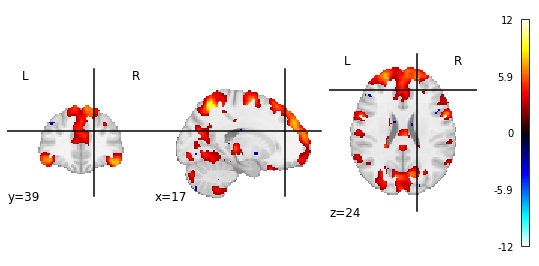

In [6]:


group_res_zscore = nib.load(f'{second_level_res_dir}omnibus_anova_z_score.nii.gz')
gm_mask_img = nib.load('masks/gm_mask_icbm152_brain.nii.gz')
group_res_zscore = math_img('img1 * img2', img1=group_res_zscore, img2=gm_mask_img)

thresholded_map, second_level_threshold = threshold_stats_img(group_res_zscore, 
                                    alpha=0.05,
                                    height_control='fdr')


print(f"second level threshold: fdr ={second_level_threshold}")

plotting.plot_stat_map(thresholded_map)
# save the thresholded map
nib.save(thresholded_map, f'{second_level_res_dir}omnibus_anova_z_score_fdr.nii.gz')
table, label_maps = get_clusters_table(group_res_zscore, stat_threshold=second_level_threshold, cluster_threshold=50, return_label_maps=True)

# create labels masker
masker = NiftiLabelsMasker(label_maps[0], standardize=False)


# run kmeans to further reduce the number of clusters
# run kmeans at the subject level: n ROIs x 6 features x 30 subjects => n x 180 matrix
from nilearn.image import load_img
all_sub_z = load_img(second_level_input) # 91, 109, 91, 180
print(all_sub_z.shape)
roi_sub_z = masker.fit_transform(all_sub_z) # 180 x n clusters

roi_sub_z_df = pd.DataFrame(roi_sub_z)

video_name_list = [f.split("video-")[1].split("_gm_masked.nii")[0] for f in second_level_input]
s_name_list = [f.split("sub-")[1].split("_z")[0] for f in second_level_input]
roi_sub_z_df['sub_video'] = [f"sub-{s}_video-{v}" for s, v in zip(s_name_list, video_name_list)]
roi_sub_z_df['video'] = video_name_list
df_grouped = roi_sub_z_df.groupby('video').mean().T
df_grouped = df_grouped.reset_index(drop=True)






In [7]:
gm_mask_img.shape

(91, 109, 91)

In [8]:
# load the original threshold map

z_orig = nib.load(f'Results/model_final/omnibus_anova_F/omnibus_anova_z_score_fdr.nii.gz')
thresholded_map = nib.load(f'{second_level_res_dir}omnibus_anova_z_score_fdr.nii.gz')


[Text(1, 0.5, 'original'), Text(1, 1.5, 'cue_offset'), Text(1, 2.5, 'both')]

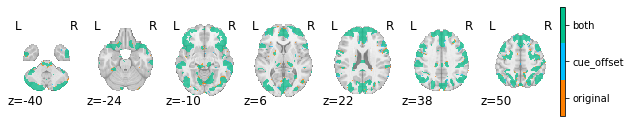

In [9]:
# plot these two maps on top of each other in the brain, with the original map in red and the new map in blue
# binarize them first
z_orig_mask = math_img('img1 != 0', img1=z_orig)
z_orig_mask = math_img('img1 * 1', img1=z_orig_mask)
thresholded_mask = math_img('img1 != 0', img1=thresholded_map)
thresholded_mask = math_img('img1 * 2', img1=thresholded_mask)

combined_mask = math_img('img1 + img2', img1=z_orig_mask, img2=thresholded_mask)


fig, (img_ax, cbar_ax) = plt.subplots(
    1,
    2,
    gridspec_kw={"width_ratios": [10.0, 0.1], "wspace": 0.0},
    figsize=(10, 2),
)
from matplotlib import colors, colorbar
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#FF8000", "#00BFFF", "#00C08B"])
plotting.plot_roi(combined_mask, cmap=cmap, axes=img_ax, display_mode="z")
norm = colors.Normalize(vmin=0, vmax=3)
cbar = colorbar.ColorbarBase(
    cbar_ax,
    ticks=[0.5, 1.5, 2.5],
    norm=norm,
    orientation="vertical",
    cmap=cmap,
    spacing="proportional",
)
cbar_ax.set_yticklabels(["original", "cue_offset", "both"])
